# Network Analysis

This section characterizes familiarity and active social structure in the baseline simulation. Longitudinal panels average across baseline seeds; static summaries at week 52 use seed 6400 where noted. Familiarity ties arise from repeated co-attendance; active social ties require sustained co-attendance and sufficient tie strength under the model rules.


In [5]:
from pathlib import Path
import sys

# notebook runs from analysis and setting up project imports
sys.path.insert(0, str(Path.cwd().resolve().parent / "analysis"))
sys.path.insert(0, str(Path.cwd().resolve().parent / "src"))
from notebook_paths import ensure_src_on_path

PROJECT_ROOT = ensure_src_on_path()
OUTPUT_DIR = PROJECT_ROOT / "outputs"
RESULTS_DIR = PROJECT_ROOT / "results"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import pandas as pd


## Accumulation of familiarity and active social ties


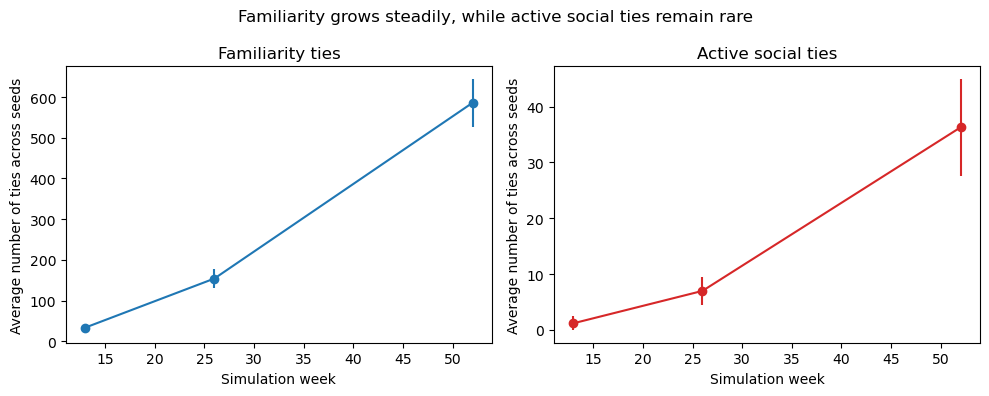

In [6]:
from soulcycle_network.analysis.io import load_master_table

master = load_master_table(OUTPUT_DIR)
baseline = master[master["scenario"] == "baseline"]
benchmark_weeks = [13, 26, 52]  # reporting checkpoints
layer_titles = {"familiarity": "Familiarity ties", "social": "Active social ties"}

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
for ax, layer, color in zip(axes, ["familiarity", "social"], ["C0", "C3"]):
    sub = baseline[(baseline["network_type"] == layer) & (baseline["week"].isin(benchmark_weeks))]
    stats = sub.groupby("week")["edges"].agg(["mean", "std"])
    ax.errorbar(stats.index, stats["mean"], yerr=stats["std"], marker="o", color=color)
    ax.set_title(layer_titles[layer])
    ax.set_xlabel("Simulation week")
    ax.set_ylabel("Average number of ties across seeds")
fig.suptitle("Familiarity grows steadily, while active social ties remain rare")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_network_growth.png", dpi=150, bbox_inches="tight")
plt.show()

Familiarity tie counts increase markedly between weeks 13, 26, and 52, whereas active social ties remain an order of magnitude smaller at each benchmark. The widening gap is consistent with a process in which repeated co-attendance generates recognition and weak ties more readily than conversion into durable social relationships. Values are simulated edge totals averaged across seeds, not relationships observed in physical studios.


## Network structure at week 52

The summary table reports structural properties of the week-52 familiarity graph for each coordination scenario. Metrics are computed on one graph per seed and then aggregated across seeds; graphs are not pooled.


In [7]:
import math

import networkx as nx
import numpy as np
import pandas as pd
from soulcycle_network.analysis.io import familiarity_graph_from_seed

LOUVAIN_SEED = 6400  # fixed for Louvain across all seeds/scenarios
SCENARIO_DIRS = [
    ("no_coordination", "No coordination"),
    ("baseline", "Baseline coordination"),
    ("high_coordination", "High coordination"),
]


def week52_familiarity_metrics(graph: nx.Graph) -> dict[str, float]:
    # structural metrics on the full undirected familiarity graph (all riders as nodes)
    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    isolates = nx.number_of_isolates(graph)
    connected = n - isolates
    components = list(nx.connected_components(graph))
    nontrivial = sum(1 for comp in components if len(comp) >= 2)
    total_components = len(components)
    largest = max((len(comp) for comp in components), default=0)
    density = nx.density(graph) if n > 1 else 0.0
    clustering = nx.average_clustering(graph) if n > 0 else 0.0
    assortativity = float("nan")
    if m > 0:
        coeff = nx.degree_assortativity_coefficient(graph)
        assortativity = float(coeff) if math.isfinite(coeff) else float("nan")
    tied = graph.subgraph([node for node, deg in graph.degree() if deg > 0]).copy()
    modularity = float("nan")
    if tied.number_of_edges() > 0:
        # Louvain on riders with at least one tie
        communities = nx.community.louvain_communities(tied, weight=None, seed=LOUVAIN_SEED)
        modularity = float(nx.community.modularity(tied, communities, weight=None))
    return {
        "nontrivial_components": float(nontrivial),
        "total_components_including_isolates": float(total_components),
        "largest_component_size": float(largest),
        "largest_share_all_riders": largest / n if n else float("nan"),
        "largest_share_connected": largest / connected if connected else float("nan"),
        "density": density,
        "average_clustering": clustering,
        "degree_assortativity": assortativity,
        "modularity": modularity,
    }


# build one metrics row per scenario
records = []
for scenario_dir, _label in SCENARIO_DIRS:
    for seed_dir in sorted((OUTPUT_DIR / scenario_dir).glob("seed_*")):
        seed = int(seed_dir.name.split("_")[1])
        graph = familiarity_graph_from_seed(seed_dir, include_isolates=True)
        row = week52_familiarity_metrics(graph)
        row["scenario"] = scenario_dir
        row["seed"] = seed
        records.append(row)

metrics_df = pd.DataFrame(records)


def mean_std(series: pd.Series) -> tuple[float, float]:
    return float(series.mean()), float(series.std(ddof=1))


def fmt_pm(mean: float, std: float, decimals: int) -> str:
    if math.isnan(mean):
        return "NA"
    return f"{mean:.{decimals}f} ± {std:.{decimals}f}"


def fmt_pm_pct(mean: float, std: float, decimals: int) -> str:
    if math.isnan(mean):
        return "NA"
    return f"{100 * mean:.{decimals}f} ± {100 * std:.{decimals}f}%"


def fmt_pm_sci_pct(mean: float, std: float) -> str:
    if math.isnan(mean):
        return "NA"
    m_pct, s_pct = 100 * mean, 100 * std
    if m_pct < 0.01:
        return f"{m_pct:.4e} ± {s_pct:.4e}%"
    return f"{m_pct:.4f} ± {s_pct:.4f}%"


def fmt_assort_mod(mean: float, std: float) -> str:
    if math.isnan(mean):
        return "NA"
    return f"{mean:.3f} ± {std:.3f}"


seed6400_baseline = metrics_df[(metrics_df["scenario"] == "baseline") & (metrics_df["seed"] == 6400)].iloc[0]
table_rows = [
    ("Nontrivial familiarity components","nontrivial_components","count",True),
    ("Largest component size","largest_component_size","count",False),
    ("Largest component share","largest_share_all_riders","pct",False),
    ("Network density","density","density",False),
    ("Average clustering coefficient","average_clustering","pct",False),
    ("Degree assortativity","degree_assortativity","assort",False),
    ("Modularity","modularity","assort",False),
]

col_labels = [label for _dir, label in SCENARIO_DIRS]
table_data = []
for metric_name, col_key, kind, show_seed6400 in table_rows:
    row_cells = [metric_name]
    for scenario_dir, _label in SCENARIO_DIRS:
        sub = metrics_df[metrics_df["scenario"] == scenario_dir][col_key]
        mu, sd = mean_std(sub)
        if kind == "count":
            text = fmt_pm(mu, sd, 1)
            if show_seed6400 and scenario_dir == "baseline":
                s6400 = int(seed6400_baseline[col_key])
                text += f" (seed 6400: {s6400})"
        elif kind == "pct":
            text = fmt_pm_pct(mu, sd, 2)
        elif kind == "density":
            text = fmt_pm_sci_pct(mu, sd)
        else:
            text = fmt_assort_mod(mu, sd)
        row_cells.append(text)
    table_data.append(row_cells)

metrics_df.to_csv(FIGURES_DIR / "02_network_structure_summary_by_seed.csv", index=False)
plt.show()
metrics_df.groupby("scenario").agg("mean").round(6)


,nontrivial_components,total_components_including_isolates,largest_component_size,largest_share_all_riders,largest_share_connected,density,average_clustering,degree_assortativity,modularity,seed
scenario,,,,,,,,,,
baseline,49.6,9549.4,55.0,0.00550,0.109350,0.000012,0.005389,-0.163947,0.936072,6404.5
high_coordination,48.3,9548.7,54.4,0.00544,0.108746,0.000012,0.004957,-0.161959,0.936284,6404.5
no_coordination,45.4,9531.8,65.2,0.00652,0.127442,0.000013,0.006903,-0.172073,0.931576,6404.5


Under all coordination conditions, familiarity networks at week 52 are sparse on the full 10,000-rider graph: tie density remains far below one percent of possible edges, and the largest connected component includes well under one percent of riders. No-coordination runs exhibit modestly more nontrivial components and somewhat larger largest components than baseline or high coordination, yet no scenario approaches a single systemwide component. Clustering coefficients remain low, indicating limited triadic closure at the population scale. Degree assortativity is negative throughout, implying that high-degree riders are not preferentially linked to one another under this definition (distinct from activity-tier assortativity). Louvain modularity near 0.93 on the subgraph of tied riders indicates strong community separation relative to a degree-preserving reference; it does not establish meaningful real-world friendship groups. All entries refer to synthetic week-52 outcomes, not the operator’s observed customer network.


## Largest familiarity components (week 52, seed 6400)


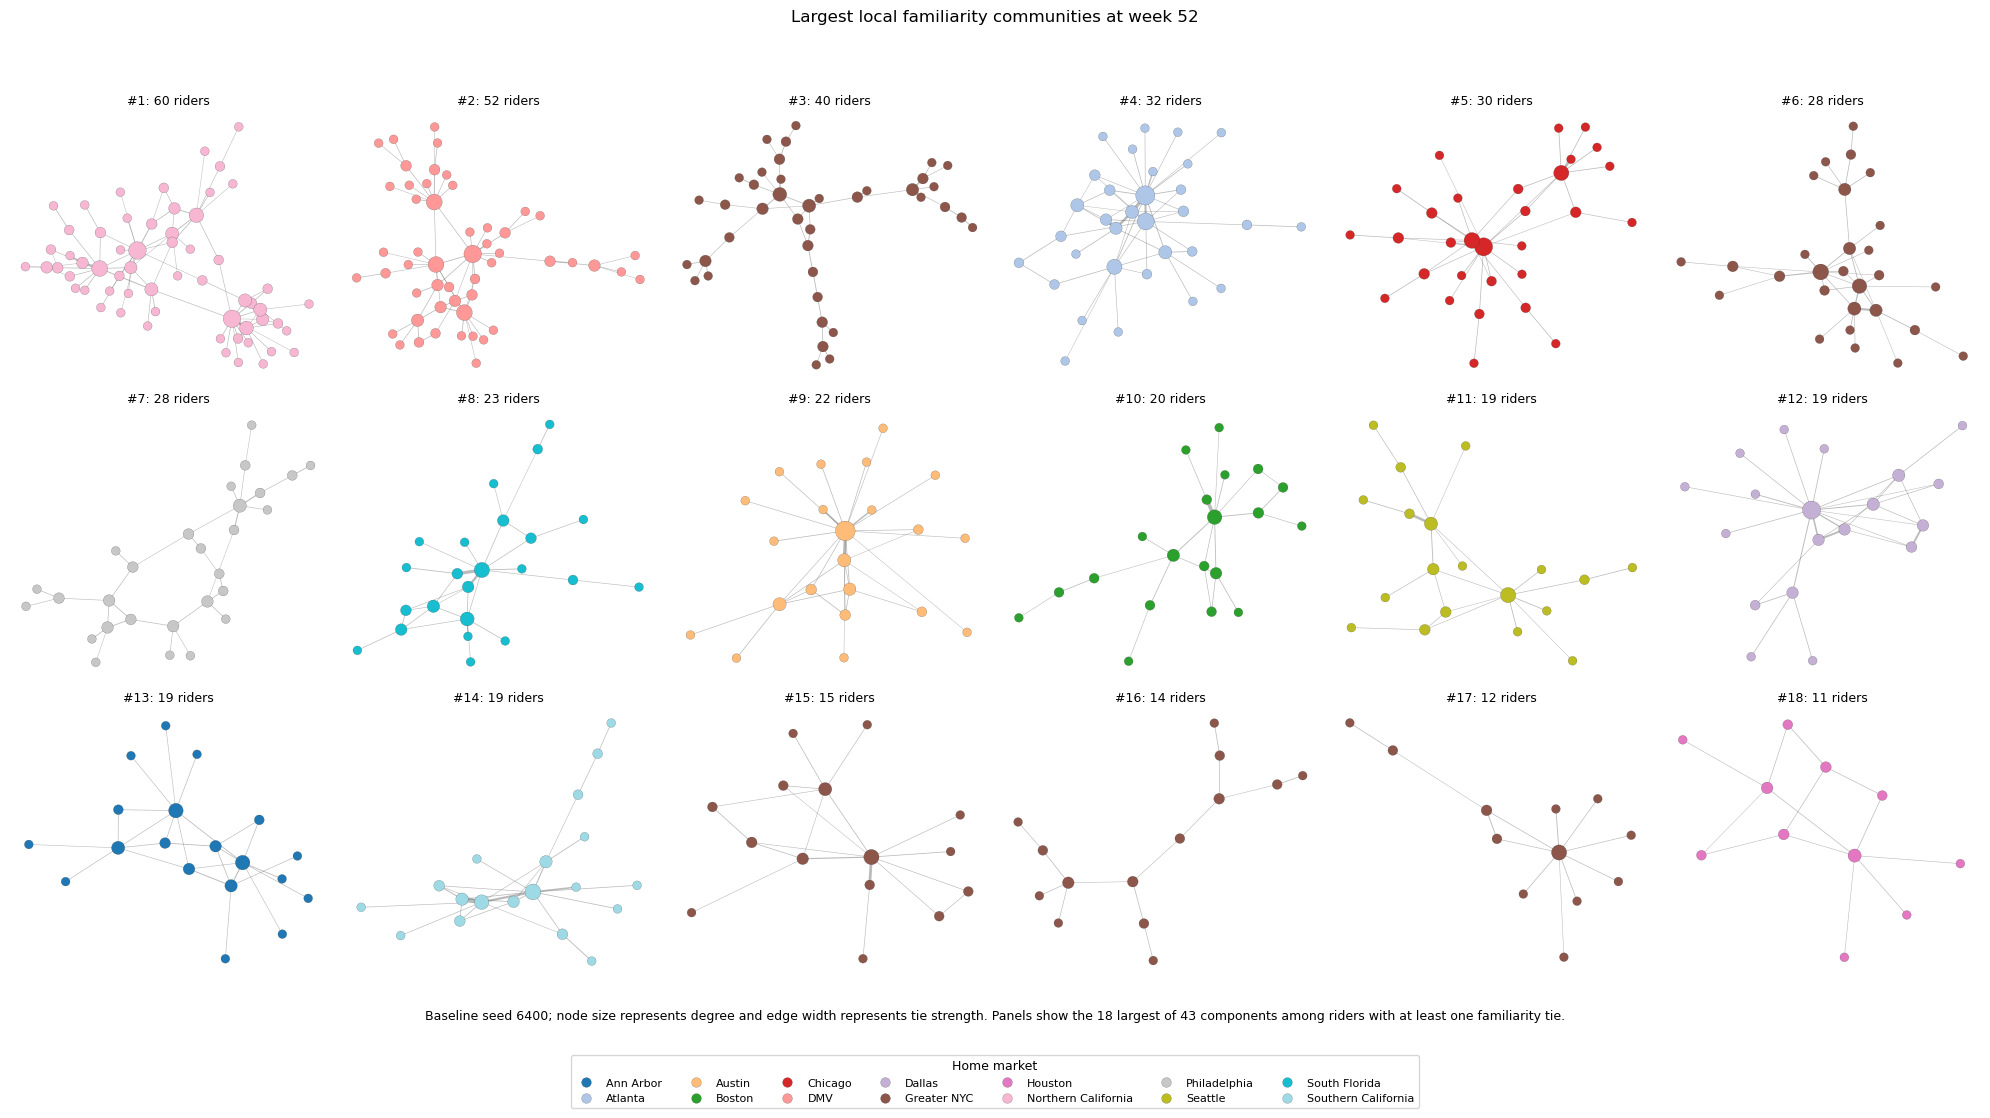

In [8]:
from matplotlib.lines import Line2D

import networkx as nx
from soulcycle_network.analysis.io import familiarity_graph_from_seed, load_seed_exports

# week 52 familiarity graph, seed 6400
TOP_N = 18
NROW, NCOL = 3, 6

seed_dir = OUTPUT_DIR / "baseline" / "seed_6400"
graph = familiarity_graph_from_seed(seed_dir, include_isolates=False) 
nodes = load_seed_exports(seed_dir)["node_attributes"].drop_duplicates("rider_id")
market_by_rider = nodes.set_index("rider_id")["home_market"].astype(str)

components = sorted(nx.connected_components(graph), key=len, reverse=True)
top_components = components[:TOP_N]
n_components_total = len(components)

top_nodes = set().union(*top_components)
top_graph = graph.subgraph(top_nodes)
strengths = [float(top_graph[u][v]["tie_strength"]) for u, v in top_graph.edges()]
s_min, s_max = min(strengths), max(strengths)
s_span = s_max - s_min if s_max > s_min else 1.0

markets = sorted(market_by_rider.reindex(list(top_nodes), fill_value="?").astype(str).unique())
market_to_idx = {m: i for i, m in enumerate(markets)}
cmap = plt.get_cmap("tab20", max(len(markets), 1))
degrees = dict(graph.degree())

fig, axes = plt.subplots(NROW, NCOL, figsize=(20, 10))
for ax, rank, comp_nodes in zip(axes.ravel(), range(1, TOP_N + 1), top_components):
    sub = graph.subgraph(comp_nodes)
    node_list = list(sub.nodes())
    node_colors = [cmap(market_to_idx[market_by_rider.get(n, "?")]) for n in node_list]
    node_sizes = [30 + 10 * degrees[n] for n in node_list]
    n = sub.number_of_nodes()
    if n == 1:
        pos = {node_list[0]: (0.0, 0.0)}
    else:
        pos = nx.spring_layout(sub,seed=6400+rank,k=2.4/(n ** 0.5),iterations=120,weight="tie_strength")
    for u, v in sub.edges():
        strength = float(sub[u][v]["tie_strength"])
        width = 0.35 + 2.2 * (strength - s_min) / s_span
        nx.draw_networkx_edges(sub, pos, edgelist=[(u, v)], ax=ax, alpha=0.4, width=width, edge_color="#555555")
    nx.draw_networkx_nodes(sub,pos,nodelist=node_list,ax=ax,node_color=node_colors,node_size=node_sizes,linewidths=0.12,edgecolors="#222222",)
    ax.set_title("#" + str(rank) + ": " + str(n) + " riders", fontsize=9)
    ax.axis("off")

for ax in axes.ravel()[len(top_components) :]:
    ax.axis("off")

fig.suptitle("Largest local familiarity communities at week 52", y=1.02, fontsize=12)
fig.text(
    0.5,
    0.01,
    "Baseline seed 6400; node size represents degree and edge width represents tie strength. "
    + "Panels show the "
    + str(len(top_components))
    + " largest of "
    + str(n_components_total)
    + " components among riders with at least one familiarity tie.",
    ha="center",
    fontsize=9,
)
market_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cmap(i),
        markeredgecolor="#222222",
        markeredgewidth=0.12,
        markersize=7,
        label=markets[i],
    )
    for i in range(len(markets))
]
fig.legend(handles=market_handles,title="Home market",loc="upper center",bbox_to_anchor=(0.5, -0.02),ncol=min(7, len(markets)),fontsize=8,title_fontsize=9,)
fig.tight_layout(rect=[0, 0.04, 1, 0.98])
fig.savefig(FIGURES_DIR / "02_top_familiarity_components.png", dpi=150, bbox_inches="tight")
plt.show()

The eighteen panels show the largest connected components among riders with at least one familiarity tie, with node color denoting home market. Familiarity structure remains local and fragmented rather than national in scope. Component topology ranges from single highly connected riders anchoring small groups to several modest hubs within larger subgraphs (patterns that are compatible with meaningful analog ties without systemwide integration). Layout coordinates are algorithmic and should not be interpreted as maps or as evidence of social leadership.


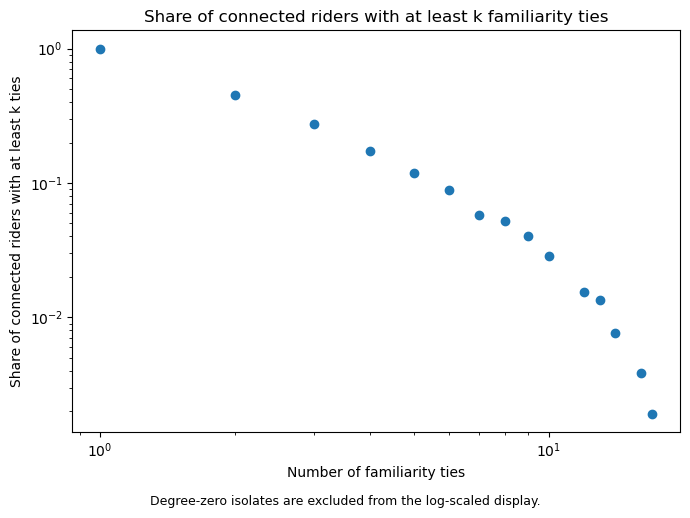

In [9]:
import numpy as np
from soulcycle_network.analysis.io import familiarity_graph_from_seed

# CCDF over connected riders only
graph_full = familiarity_graph_from_seed(seed_dir, include_isolates=True)
degrees = np.fromiter((d for _, d in graph_full.degree()), dtype=int)
connected_deg = degrees[degrees > 0]
unique = np.unique(connected_deg)
ccdf = np.array([np.mean(connected_deg >= k) for k in unique])
mask = (unique > 0) & (ccdf > 0)
fig, ax = plt.subplots(figsize=(7, 5))
ax.loglog(unique[mask], ccdf[mask], marker="o", linestyle="none")
ax.set_xlabel("Number of familiarity ties")
ax.set_ylabel("Share of connected riders with at least k ties")
ax.set_title("Share of connected riders with at least k familiarity ties")
fig.text(0.5, -0.02, "Degree-zero isolates are excluded from the log-scaled display.", ha="center", fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_familiarity_degree_ccdf.png", dpi=150, bbox_inches="tight")
plt.show()

For connected riders, the share with at least *k* familiarity ties declines gradually on a log–log scale, leaving a minority with many partners. The shape parallels the hub-and-periphery motifs visible in the component figure but does not constitute a formal test of scale-free behavior. Riders with zero familiarity ties are excluded from the display because they cannot be represented on a log-scaled degree axis.


## Activity tiers and conversion from co-attendance


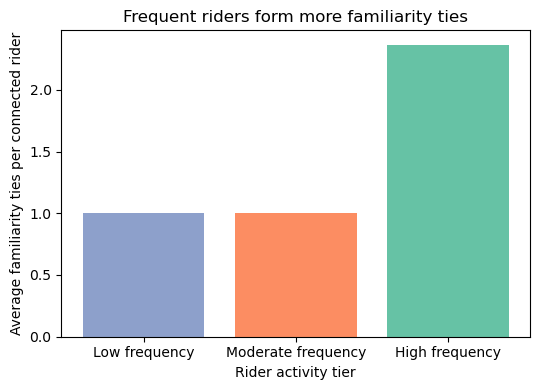

In [10]:
row = master[(master["scenario"]=="baseline")&(master["seed"]==6400)&(master["network_type"]=="familiarity")&(master["week"] == 52)].iloc[0]
# mean familiarity degree by activity level (connected riders only)
tier_labels = ["Low frequency", "Moderate frequency", "High frequency"]
cols = ["mean_degree_low_frequency","mean_degree_moderate_frequency","mean_degree_high_frequency",]
vals = [row[c] for c in cols if c in row and pd.notna(row[c])]
if vals:
    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.bar(tier_labels[: len(vals)], vals, color=["#8da0cb", "#fc8d62", "#66c2a5"][: len(vals)])
    ax.set_xlabel("Rider activity tier")
    ax.set_ylabel("Average familiarity ties per connected rider")
    ax.set_title("Frequent riders form more familiarity ties")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "02_mean_degree_by_activity_tier.png", dpi=150, bbox_inches="tight")
    plt.show()

At week 52 (baseline, seed 6400), mean familiarity degree among connected riders increases monotonically from low- to high-frequency activity tiers. Greater attendance plausibly raises the number of distinct co-attendees available for repeated exposure, though the bars do not demonstrate preferential attachment among frequent riders (activity-tier assortativity in the simulation is near zero). Averages are conditional on having at least one familiarity tie within the tier.


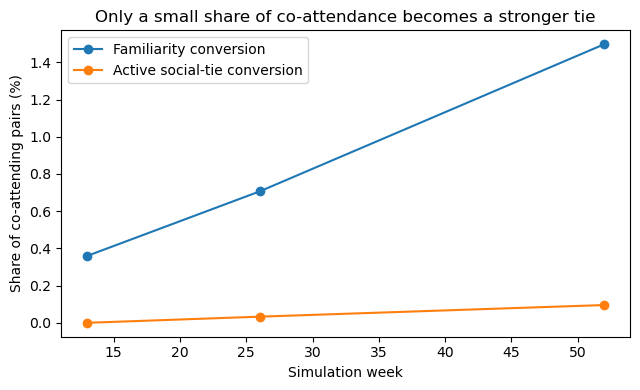

In [11]:
link = master[(master["scenario"]=="baseline")&(master["seed"]==6400)&(master["network_type"]=="familiarity")& (master["week"].isin([13, 26, 52]))]
# share of co-attending dyads that cross familiarity vs social thresholds
if "share_familiar_of_coattending" in link.columns:
    fig, ax = plt.subplots(figsize=(6.5, 4))
    ax.plot(link["week"],link["share_familiar_of_coattending"] * 100, marker="o",label="Familiarity conversion")
    ax.plot(link["week"],link["share_social_of_coattending"] * 100, marker="o",label="Active social-tie conversion")
    ax.set_xlabel("Simulation week")
    ax.set_ylabel("Share of co-attending pairs (%)")
    ax.legend()
    ax.set_title("Only a small share of co-attendance becomes a stronger tie")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "02_linking_progression.png", dpi=150, bbox_inches="tight")
    plt.show()

Co-attending dyads (unordered pairs of riders who share at least one class) cross the familiarity threshold for a slowly rising share of pairs, reaching roughly 1.5% by week 52. Conversion to active social ties remains below one-tenth of one percent at every benchmark, marking a persistent bottleneck after familiarity forms. The accumulating set of familiar but non-social pairs defines a plausible target population for coordination support in a digital layer; the simulation does not model adoption or product use.
